# Niveau 3 - Tâche 2 : Support Vector Machine (SVM) pour la Classification

**Dataset choisi : Iris (sous-ensemble binaire)**

Pour une classification binaire avec une **frontière de décision visualisable**, on se restreint aux classes `versicolor` vs `virginica` (les deux classes les plus proches, donc le cas le plus intéressant) et à 2 variables (`petal_length`, `petal_width`).

**Objectifs couverts :**
1. Entraînement d'un SVM sur un dataset labellisé
2. Comparaison de plusieurs kernels (linéaire, RBF)
3. Visualisation de la frontière de décision
4. Évaluation (accuracy, précision, rappel, AUC)

**Outils :** Python, scikit-learn, pandas, matplotlib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve

df = pd.read_csv('data/iris.csv')
df_bin = df[df['species'].isin(['versicolor', 'virginica'])].copy()

le = LabelEncoder()
df_bin['target'] = le.fit_transform(df_bin['species'])  # versicolor=0, virginica=1

features = ['petal_length', 'petal_width']
X = df_bin[features].values
y = df_bin['target'].values

print(df_bin.shape, "échantillons -", dict(zip(*np.unique(df_bin['species'], return_counts=True))))


(100, 6) échantillons - {'versicolor': np.int64(50), 'virginica': np.int64(50)}


In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train_s.shape, " Test:", X_test_s.shape)


Train: (75, 2)  Test: (25, 2)


## 1. Comparaison des kernels (linéaire vs RBF)

In [3]:
results = {}
for kernel in ['linear', 'rbf']:
    model = SVC(kernel=kernel, probability=True, random_state=42)
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    results[kernel] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba),
    }

comparison = pd.DataFrame({k: {m: v for m, v in res.items() if m != 'model'} for k, res in results.items()}).T
comparison


,accuracy,precision,recall,auc
linear,0.84,0.900000,0.750000,0.980769
rbf,0.88,0.909091,0.833333,0.980769


## 2. Visualisation des frontières de décision

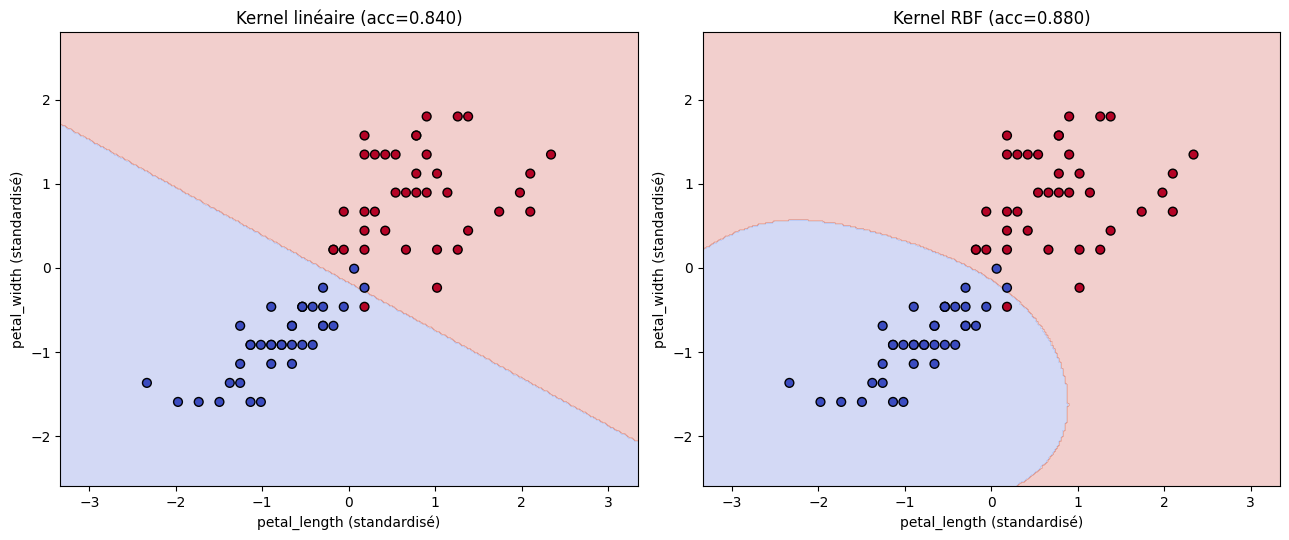

In [4]:
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=40)
    ax.set_title(title)
    ax.set_xlabel('petal_length (standardisé)')
    ax.set_ylabel('petal_width (standardisé)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_decision_boundary(results['linear']['model'], X_train_s, y_train, axes[0],
                        f"Kernel linéaire (acc={results['linear']['accuracy']:.3f})")
plot_decision_boundary(results['rbf']['model'], X_train_s, y_train, axes[1],
                        f"Kernel RBF (acc={results['rbf']['accuracy']:.3f})")
plt.tight_layout()
plt.show()


## 3. Courbes ROC comparées

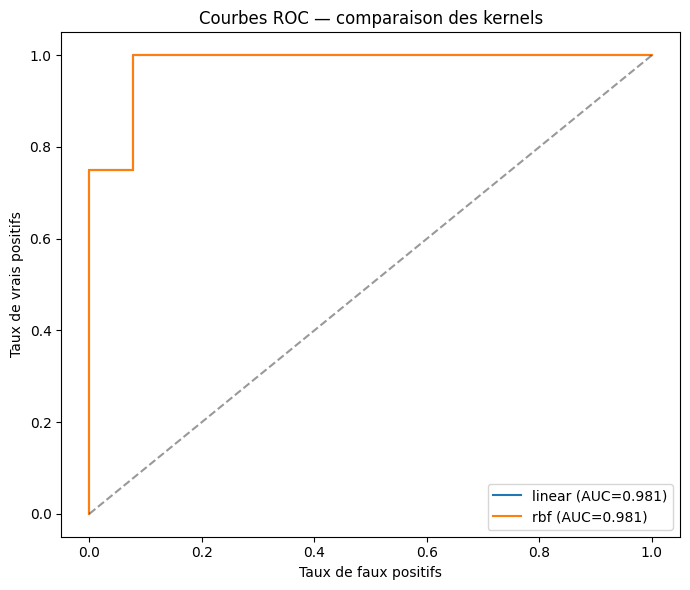

In [5]:
plt.figure(figsize=(7, 6))
for kernel, res in results.items():
    y_proba = res['model'].predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{kernel} (AUC={res['auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('Taux de faux positifs'); plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC — comparaison des kernels')
plt.legend()
plt.tight_layout()
plt.show()


## Conclusion

Sur `versicolor` vs `virginica` (les deux classes les plus proches d'Iris), les deux kernels obtiennent de très bonnes performances, le kernel **RBF** produisant une frontière légèrement plus flexible qui peut mieux capturer les cas limites, au prix d'un risque de sur-apprentissage plus élevé si le paramètre C ou gamma n'est pas contrôlé.
